## IMPORT LIBRARIES

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

## LOAD DATA

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

## VISUALIZE SAMPLE IMAGES

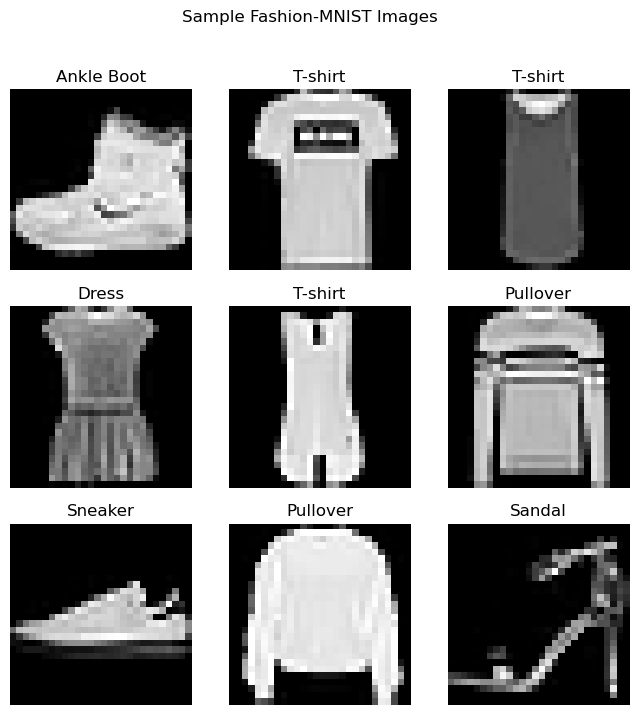

In [3]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']   # creaters already defined

plt.figure(figsize=(8,8))          # Creates a blank canvas for plotting images
for i in range(9):                 # We will display first 9 images
    plt.subplot(3,3,i+1)     # creates a 3×3 grid 3 rows 3 columns Total = 9 images
    plt.imshow(X_train[i], cmap='gray') # Displays image
    plt.title(class_names[y_train[i]])
    plt.axis('off') # Hides x and y axis for clean view
plt.suptitle("Sample Fashion-MNIST Images")
plt.show()

## PREPROCESSING

In [4]:
# Normalize pixel values
# Original images have pixel values: 0 to 255 so It divides every pixel value by 255
X_train = X_train / 255.0 # After this: 0 to 1   why Helps model learn faster, makes value consistent
X_test = X_test / 255.0

# Original shape: (60000, 28, 28)  After reshape: (60000, 28, 28, 1) where 60000 number of images, 28,28 size of images,1 graysacle channel
X_train = X_train.reshape(-1, 28, 28, 1) # -1 → number of images (auto)
X_test = X_test.reshape(-1, 28, 28, 1)  # Height = 28 pixels, Width = 28 pixels, So total pixels: 28 × 28 = 784 pixels

y_train = to_categorical(y_train, 10) # Each output lable name value is converted into binary format
y_test = to_categorical(y_test, 10)

## BUILD CNN MODEL

In [5]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1))) # Looks at small parts of image (3×3 filter) Detects features like edges, patterns So it learns 32 different features
model.add(MaxPooling2D(2,2))  # Takes 2×2 area Keeps only maximum value

model.add(Conv2D(64, (3,3), activation='relu'))  # Input = 13×13 image size 32 feature maps (channels)
model.add(MaxPooling2D(2,2))

model.add(Flatten()) # Converts data into 1D vector Required for Dense layer

model.add(Dense(128, activation='relu'))  # Has 128 neurons Learns patterns from extracted features
model.add(Dense(10, activation='softmax'))  # 10 → number of classes (Fashion MNIST) Each neuron = one class Converts output into probabilities Highest value = predicted class


C:\Users\omsod\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',    # It measures how wrong your model’s predictions are
    metrics=['accuracy']
)

## TRAIN MODEL

In [ ]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8390 - loss: 0.4423 - val_accuracy: 0.8751 - val_loss: 0.3519
Epoch 2/10
 353/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8822 - loss: 0.3180

## VISUALIZE TRAINING RESULTS

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

## EVALUATE MODEL

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy * 100)

## SHOW PREDICTIONS

In [ ]:
predictions = model.predict(X_test)

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    pred_label = np.argmax(predictions[i])
    plt.title("Pred: " + class_names[pred_label])
    plt.axis('off')
plt.suptitle("Model Predictions")
plt.show()